<a href="https://colab.research.google.com/github/Janeyy-A/PINN_KAN-PIKAN/blob/main/PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 2D Advection–Diffusion  
## ADI–Crank–Nicolson Ground Truth + PINN

We solve:

\[
c_t + u c_x + v c_y = D (c_{xx} + c_{yy}),
\quad (x,y)\in(0,L)^2, \quad t\in[0,T]
\]

### Parameters
- L = 2
- u = 1, v = 1
- D = 1/2
- **IC: c(0,x,y) = x + y**
- **Dirichlet BC: constant = 1.0 (uniform on all boundaries)**
- **dx = dy = L/Nx = L/Ny = 0.025 (Nx=Ny=80)**

Ground truth: IMEX scheme  
- Upwind explicit advection  
- ADI Crank–Nicolson diffusion  

PINN enforces:
- PDE residual
- Initial condition (IC: x+y)
- Boundary conditions (BC: constant 1.0)

**Stopping conditions:**
- Early stop if total loss change < 1e-5 for 200 consecutive epochs
- Hard wall: 1 hour of wall-clock training time


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:

@dataclass
class Params:
    L: float = 2.0
    Nx: int = 80
    Ny: int = 80
    u: float = 1.0
    v: float = 1.0
    D: float = 0.5
    T: float = 1.0
    dt: float = 2e-3
    n_f: int = 40000
    n_ic: int = 10000
    n_bc: int = 16000
    epochs: int = 8000
    lr: float = 1e-3
    print_every: int = 400

p = Params()

dx = p.L / p.Nx
dy = p.L / p.Ny
Nt = int(p.T / p.dt)

print("dx=", dx, "dy=", dy, "Nt=", Nt)


dx= 0.025 dy= 0.025 Nt= 500


In [3]:

def ic_xy(x, y):
    return x + y          # IC: x + y

def bc_left(t, y):
    return np.ones_like(y)   # BC constant = 1.0

def bc_right(t, y):
    return np.ones_like(y)   # BC constant = 1.0

def bc_bottom(t, x):
    return np.ones_like(x)   # BC constant = 1.0

def bc_top(t, x):
    return np.ones_like(x)   # BC constant = 1.0


In [4]:

def thomas(a,b,c,d):
    n = len(b)
    cp = np.zeros(n-1)
    dp = np.zeros(n)

    cp[0] = c[0]/b[0]
    dp[0] = d[0]/b[0]

    for i in range(1,n-1):
        denom = b[i] - a[i-1]*cp[i-1]
        cp[i] = c[i]/denom
        dp[i] = (d[i]-a[i-1]*dp[i-1])/denom

    denom = b[-1] - a[-1]*cp[-1]
    dp[-1] = (d[-1]-a[-1]*dp[-2])/denom

    x = np.zeros(n)
    x[-1] = dp[-1]
    for i in reversed(range(n-1)):
        x[i] = dp[i] - cp[i]*x[i+1]

    return x


In [5]:

def solve_2d():
    x = np.linspace(0,p.L,p.Nx+1)
    y = np.linspace(0,p.L,p.Ny+1)
    t = np.linspace(0,p.T,Nt+1)

    C = np.zeros((Nt+1,p.Ny+1,p.Nx+1))

    X,Y = np.meshgrid(x,y,indexing='xy')
    C[0] = ic_xy(X,Y)

    rx = p.D*p.dt/(2*dx*dx)
    ry = p.D*p.dt/(2*dy*dy)

    ax = -rx*np.ones(p.Nx-2)
    bx = (1+2*rx)*np.ones(p.Nx-1)
    cx = -rx*np.ones(p.Nx-2)

    ay = -ry*np.ones(p.Ny-2)
    by = (1+2*ry)*np.ones(p.Ny-1)
    cy = -ry*np.ones(p.Ny-2)

    for n in range(Nt):
        U = C[n].copy()

        # explicit advection
        A = np.zeros_like(U)
        A[:,1:-1] += p.u*(U[:,1:-1]-U[:,:-2])/dx
        A[1:-1,:] += p.v*(U[1:-1,:]-U[:-2,:])/dy

        Lap = np.zeros_like(U)
        Lap[1:-1,1:-1] = (
            (U[1:-1,2:]-2*U[1:-1,1:-1]+U[1:-1,:-2])/(dx*dx)
            +(U[2:,1:-1]-2*U[1:-1,1:-1]+U[:-2,1:-1])/(dy*dy)
        )

        RHS = U - p.dt*A + (p.D*p.dt/2)*Lap

        # x-sweep
        Ustar = U.copy()
        for j in range(1,p.Ny):
            d = RHS[j,1:-1]
            Ustar[j,1:-1] = thomas(ax,bx,cx,d)

        # y-sweep
        Un = Ustar.copy()
        for i in range(1,p.Nx):
            d = Ustar[1:-1,i]
            Un[1:-1,i] = thomas(ay,by,cy,d)

        C[n+1] = Un

    return x,y,t,C

x,y,t,C = solve_2d()
print("Ground truth shape:",C.shape)


Ground truth shape: (501, 81, 81)


In [6]:

class MLP(nn.Module):
    def __init__(self,width=128,depth=6):
        super().__init__()
        layers = [nn.Linear(3,width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width,width), nn.Tanh()]
        layers += [nn.Linear(width,1)]
        self.net = nn.Sequential(*layers)

    def forward(self,X):
        return self.net(X)

model = MLP().to(device)
model


MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [7]:

def residual(X):
    X = X.clone().requires_grad_(True)
    c = model(X)
    grads = torch.autograd.grad(c,X,torch.ones_like(c),create_graph=True)[0]

    ct = grads[:,0:1]
    cx = grads[:,1:2]
    cy = grads[:,2:3]

    cxx = torch.autograd.grad(cx,X,torch.ones_like(cx),create_graph=True)[0][:,1:2]
    cyy = torch.autograd.grad(cy,X,torch.ones_like(cy),create_graph=True)[0][:,2:3]

    return ct + p.u*cx + p.v*cy - p.D*(cxx+cyy)


## PINN training + accuracy + visualization
The previous cells defined the PDE residual. The following cells:
1) sample IC/BC/collocation points,  
2) train the PINN,  
3) compute accuracy vs ADI-CN ground truth, and  
4) visualize GT vs PINN vs error as heatmaps.


In [8]:
# =========================
# 6) PINN datasets (IC/BC/collocation)
# =========================
def to_torch(a: np.ndarray) -> torch.Tensor:
    return torch.tensor(a, dtype=torch.float32, device=device).view(-1, 1)

def sample_ic(n: int, L: float):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.zeros(n)
    c_ = x_ + y_            # IC: x + y
    return x_, y_, t_, c_

def sample_bc(n: int, L: float, T: float):
    n_each = n // 4
    BC_VAL = 1.0            # constant Dirichlet BC

    # x=0
    tL = np.random.rand(n_each) * T
    yL = np.random.rand(n_each) * L
    xL = np.zeros(n_each)
    cL = np.full(n_each, BC_VAL)

    # x=L
    tR = np.random.rand(n_each) * T
    yR = np.random.rand(n_each) * L
    xR = np.ones(n_each) * L
    cR = np.full(n_each, BC_VAL)

    # y=0
    tB = np.random.rand(n_each) * T
    xB = np.random.rand(n_each) * L
    yB = np.zeros(n_each)
    cB = np.full(n_each, BC_VAL)

    # y=L
    tT = np.random.rand(n_each) * T
    xT = np.random.rand(n_each) * L
    yT = np.ones(n_each) * L
    cT = np.full(n_each, BC_VAL)

    x = np.concatenate([xL, xR, xB, xT])
    y = np.concatenate([yL, yR, yB, yT])
    t_ = np.concatenate([tL, tR, tB, tT])
    c = np.concatenate([cL, cR, cB, cT])
    return x, y, t_, c

def sample_collocation(n: int, L: float, T: float):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.random.rand(n) * T
    return x_, y_, t_

x_ic, y_ic, t_ic, c_ic = sample_ic(p.n_ic, p.L)
x_bc, y_bc, t_bc, c_bc = sample_bc(p.n_bc, p.L, p.T)
x_f,  y_f,  t_f        = sample_collocation(p.n_f, p.L, p.T)

X_ic = torch.cat([to_torch(t_ic), to_torch(x_ic), to_torch(y_ic)], dim=1); Y_ic = to_torch(c_ic)
X_bc = torch.cat([to_torch(t_bc), to_torch(x_bc), to_torch(y_bc)], dim=1); Y_bc = to_torch(c_bc)
X_f  = torch.cat([to_torch(t_f),  to_torch(x_f),  to_torch(y_f )], dim=1)

print('IC', X_ic.shape, 'BC', X_bc.shape, 'F', X_f.shape)


IC torch.Size([10000, 3]) BC torch.Size([16000, 3]) F torch.Size([40000, 3])


In [9]:
# =========================
# 7) Train PINN  (with early-stop + 1-hour wall-clock limit)
# =========================
import time

w_f = 1.0
w_ic = 10.0
w_bc = 10.0

opt = torch.optim.Adam(model.parameters(), lr=p.lr)
loss_hist = []

# ---- stopping-condition hyper-params ----
EARLY_STOP_THRESH = 1e-5   # min absolute improvement in total loss
EARLY_STOP_PATIENCE = 200  # consecutive epochs without improvement
MAX_TRAIN_SECONDS = 3600   # 1 hour hard wall

best_loss = float('inf')
no_improve_count = 0
stop_reason = 'completed all epochs'

train_start = time.time()

for epoch in range(1, p.epochs + 1):
    # --- wall-clock check ---
    elapsed = time.time() - train_start
    if elapsed >= MAX_TRAIN_SECONDS:
        stop_reason = f'1-hour wall-clock limit reached at epoch {epoch}'
        break

    opt.zero_grad()

    loss_ic = ((model(X_ic) - Y_ic)**2).mean()
    loss_bc = ((model(X_bc) - Y_bc)**2).mean()

    r = residual(X_f)
    loss_f = (r**2).mean()

    loss = w_f*loss_f + w_ic*loss_ic + w_bc*loss_bc
    loss.backward()
    opt.step()

    loss_val = loss.item()
    loss_hist.append([loss_val, loss_f.item(), loss_ic.item(), loss_bc.item()])

    # --- early-stop check ---
    if best_loss - loss_val > EARLY_STOP_THRESH:
        best_loss = loss_val
        no_improve_count = 0
    else:
        no_improve_count += 1

    if no_improve_count >= EARLY_STOP_PATIENCE:
        stop_reason = (f'early stop: no improvement > {EARLY_STOP_THRESH:.0e} '
                       f'for {EARLY_STOP_PATIENCE} consecutive epochs (epoch {epoch})')
        break

    if epoch % p.print_every == 0 or epoch == 1:
        print(f'Epoch {epoch:5d} | total {loss_val:.3e} | f {loss_f.item():.3e} '
              f'| ic {loss_ic.item():.3e} | bc {loss_bc.item():.3e} '
              f'| elapsed {elapsed:.1f}s')

total_elapsed = time.time() - train_start
print(f'\n>>> Training stopped: {stop_reason}')
print(f'>>> Total wall-clock time: {total_elapsed:.1f}s  ({total_elapsed/60:.2f} min)')
print(f'>>> Epochs completed: {len(loss_hist)}')


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     1 | total 5.334e+01 | f 9.260e-05 | ic 4.437e+00 | bc 8.963e-01 | elapsed 0.0s
Epoch   400 | total 1.553e+00 | f 1.923e-01 | ic 6.014e-02 | bc 7.592e-02 | elapsed 45.2s
Epoch   800 | total 8.268e-01 | f 1.441e-01 | ic 2.666e-02 | bc 4.161e-02 | elapsed 91.1s
Epoch  1200 | total 3.831e-01 | f 5.036e-02 | ic 1.117e-02 | bc 2.211e-02 | elapsed 139.3s
Epoch  1600 | total 2.975e-01 | f 3.401e-02 | ic 5.672e-03 | bc 2.068e-02 | elapsed 191.7s
Epoch  2000 | total 2.047e-01 | f 2.530e-02 | ic 5.278e-03 | bc 1.266e-02 | elapsed 242.5s
Epoch  2400 | total 5.035e-01 | f 1.473e-01 | ic 1.850e-02 | bc 1.712e-02 | elapsed 294.2s
Epoch  2800 | total 1.525e-01 | f 2.144e-02 | ic 3.927e-03 | bc 9.178e-03 | elapsed 345.6s
Epoch  3200 | total 4.038e-01 | f 7.877e-02 | ic 1.176e-02 | bc 2.074e-02 | elapsed 397.4s
Epoch  3600 | total 1.237e-01 | f 1.771e-02 | ic 3.036e-03 | bc 7.564e-03 | elapsed 449.3s
Epoch  4000 | total 2.702e-01 | f 7.037e-02 | ic 5.802e-03 | bc 1.418e-02 | elapsed 500.7s

>>

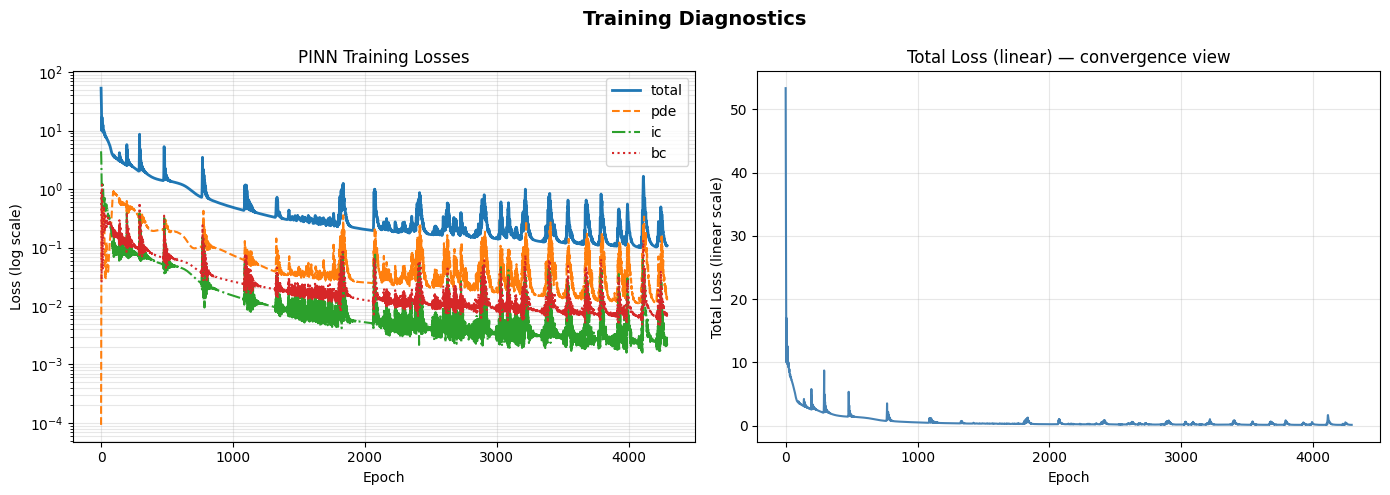

Accuracy vs ground truth:
       t       relL2         MAE           MSE
   0.000   3.037e-02   3.089e-02     4.320e-03
   0.250   3.544e-01   3.244e-01     2.319e-01
   0.500   4.569e-01   3.764e-01     2.683e-01
   0.750   5.133e-01   3.998e-01     2.863e-01
   1.000   5.378e-01   4.074e-01     2.923e-01


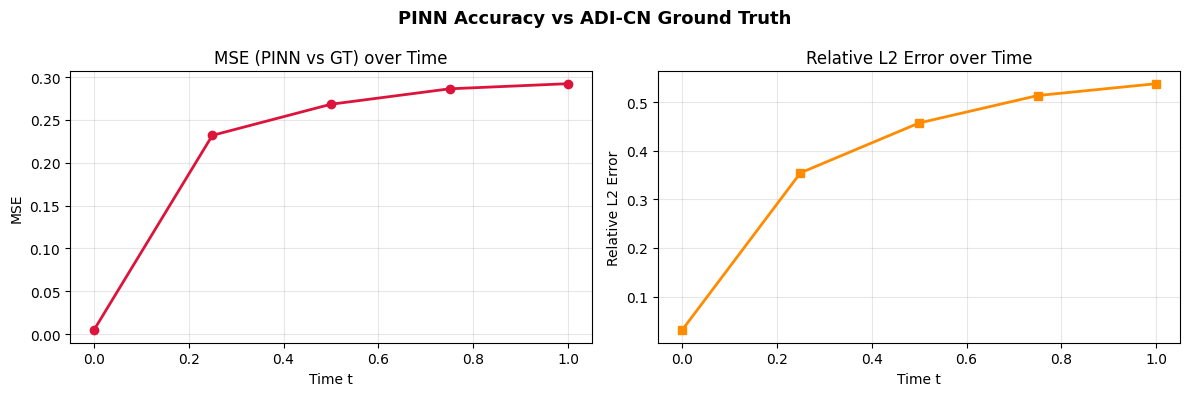

In [10]:
# =========================
# 8) Accuracy vs Ground Truth + Training Curves
# =========================
loss_hist = np.array(loss_hist)

# ---- (a) Training loss curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(loss_hist[:, 0], label='total', linewidth=2)
ax.semilogy(loss_hist[:, 1], label='pde',   linewidth=1.5, linestyle='--')
ax.semilogy(loss_hist[:, 2], label='ic',    linewidth=1.5, linestyle='-.')
ax.semilogy(loss_hist[:, 3], label='bc',    linewidth=1.5, linestyle=':')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)')
ax.set_title('PINN Training Losses')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.plot(loss_hist[:, 0], linewidth=1.5, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Total Loss (linear scale)')
ax.set_title('Total Loss (linear) — convergence view')
ax.grid(True, alpha=0.3)

plt.suptitle('Training Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- helper functions ----
@torch.no_grad()
def predict_on_grid(tval: float) -> np.ndarray:
    Xg, Yg = np.meshgrid(x, y, indexing='xy')
    tcol = np.full_like(Xg.ravel(), tval, dtype=np.float32)
    inp = np.column_stack([tcol, Xg.ravel().astype(np.float32), Yg.ravel().astype(np.float32)])
    inp_t = torch.tensor(inp, device=device)
    pred = model(inp_t).detach().cpu().numpy().reshape(y.size, x.size)
    return pred

def rel_l2(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm((a - b).ravel()) / (np.linalg.norm(b.ravel()) + 1e-12))

def mae(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean(np.abs(a - b)))

def mse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.mean((a - b) ** 2))

# ---- (b) Accuracy table ----
times_eval = [0.0, 0.25 * p.T, 0.5 * p.T, 0.75 * p.T, p.T]
metrics = []
for tt in times_eval:
    idx = int(round(tt / p.dt))
    gt   = C[idx]
    pred = predict_on_grid(t[idx])
    metrics.append([t[idx], rel_l2(pred, gt), mae(pred, gt), mse(pred, gt)])

print('Accuracy vs ground truth:')
print(f'  {"t":>6}  {"relL2":>10}  {"MAE":>10}  {"MSE":>12}')
for tt, rl2, m, ms in metrics:
    print(f'  {tt:6.3f}  {rl2:10.3e}  {m:10.3e}  {ms:12.3e}')

# ---- (c) MSE over time plot ----
mse_vals  = [ms  for _, _, _, ms  in metrics]
rl2_vals  = [rl2 for _, rl2, _, _  in metrics]
time_vals = [tt  for tt, _, _, _   in metrics]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(time_vals, mse_vals, marker='o', linewidth=2, color='crimson')
axes[0].set_xlabel('Time t'); axes[0].set_ylabel('MSE')
axes[0].set_title('MSE (PINN vs GT) over Time')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_vals, rl2_vals, marker='s', linewidth=2, color='darkorange')
axes[1].set_xlabel('Time t'); axes[1].set_ylabel('Relative L2 Error')
axes[1].set_title('Relative L2 Error over Time')
axes[1].grid(True, alpha=0.3)

plt.suptitle('PINN Accuracy vs ADI-CN Ground Truth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


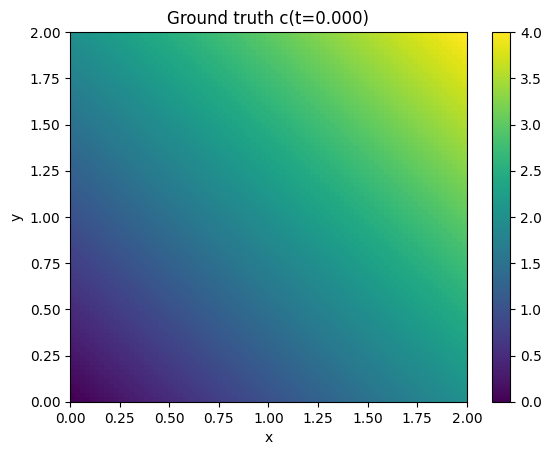

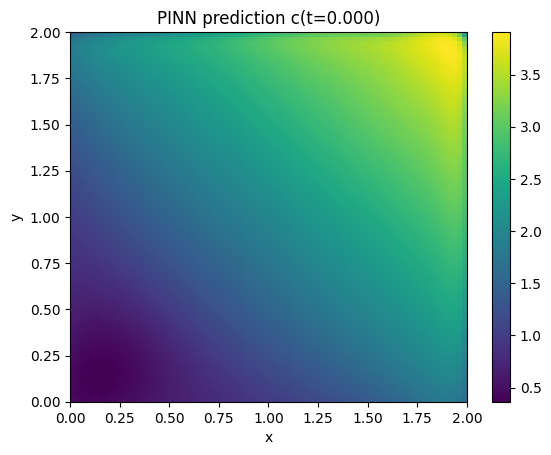

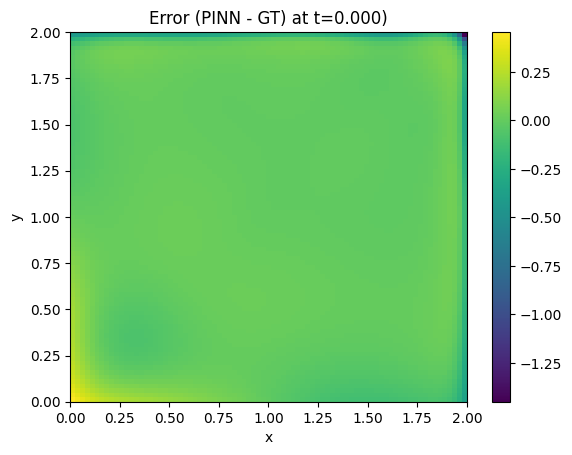

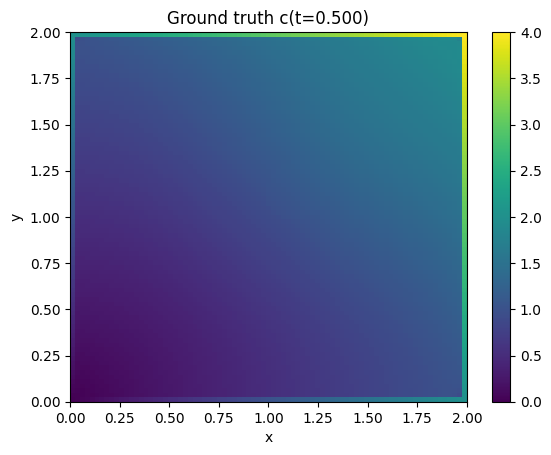

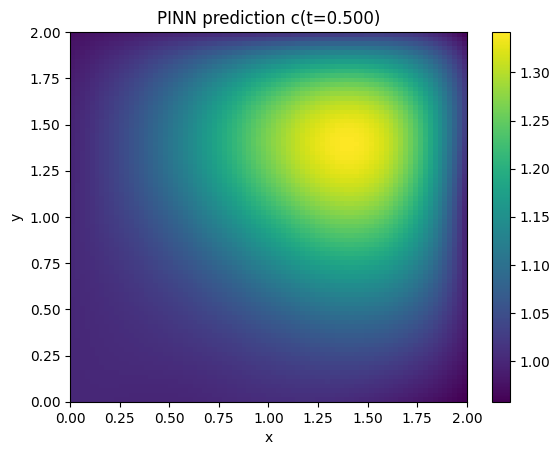

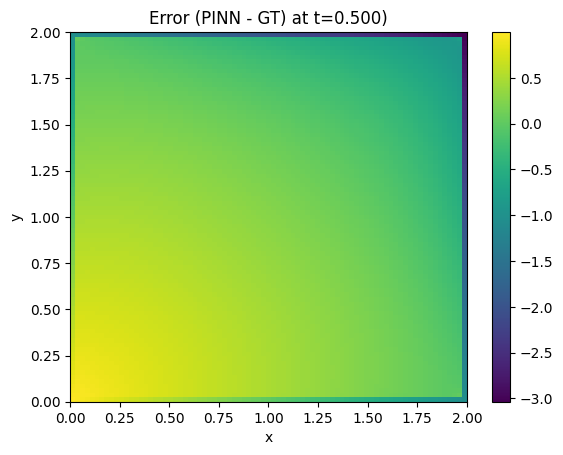

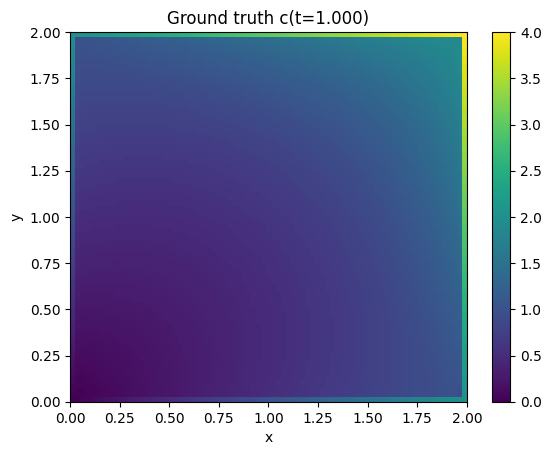

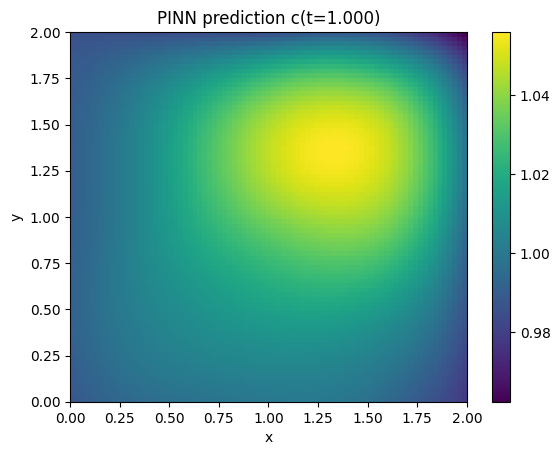

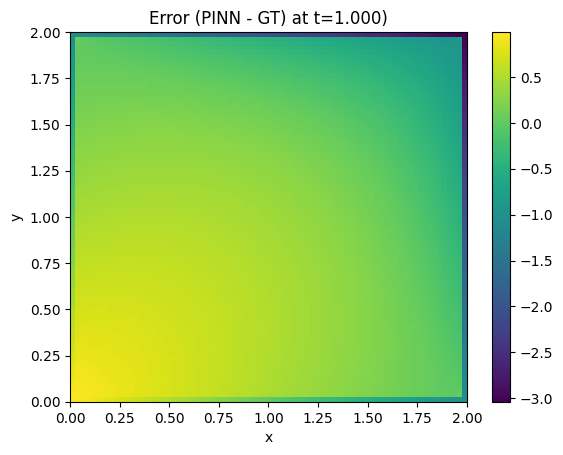

In [11]:
# =========================
# 9) Visualization: GT vs PINN vs Error (heatmaps)
# =========================
def show_heatmap(U, title=''):
    plt.figure()
    plt.imshow(U, origin='lower', extent=[0,p.L,0,p.L], aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('x'); plt.ylabel('y')
    plt.show()

for tt in [0.0, 0.5*p.T, p.T]:
    idx = int(round(tt / p.dt))
    gt = C[idx]
    pred = predict_on_grid(t[idx])
    err = pred - gt

    show_heatmap(gt,   title=f'Ground truth c(t={t[idx]:.3f})')
    show_heatmap(pred, title=f'PINN prediction c(t={t[idx]:.3f})')
    show_heatmap(err,  title=f'Error (PINN - GT) at t={t[idx]:.3f})')
